In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

In [2]:
DATA_PATH = Path("../data/processed/sardinia_hourly.parquet")

df = pd.read_parquet(DATA_PATH)

display(df.head())

print(f"Shape: {df.shape}")
print(f"Start: {df.index.min()}")
print(f"End:   {df.index.max()}")

,Total Load [MW],Forecast Total Load [MW]
Date,,
2023-01-01 00:00:00+01:00,806.13675,833.01000
2023-01-01 01:00:00+01:00,783.55525,779.20525
2023-01-01 02:00:00+01:00,753.62675,749.15025
2023-01-01 03:00:00+01:00,736.34950,739.18250
2023-01-01 04:00:00+01:00,723.29950,749.01150


Shape: (32975, 2)
Start: 2023-01-01 00:00:00+01:00
End:   2026-10-05 23:00:00+02:00


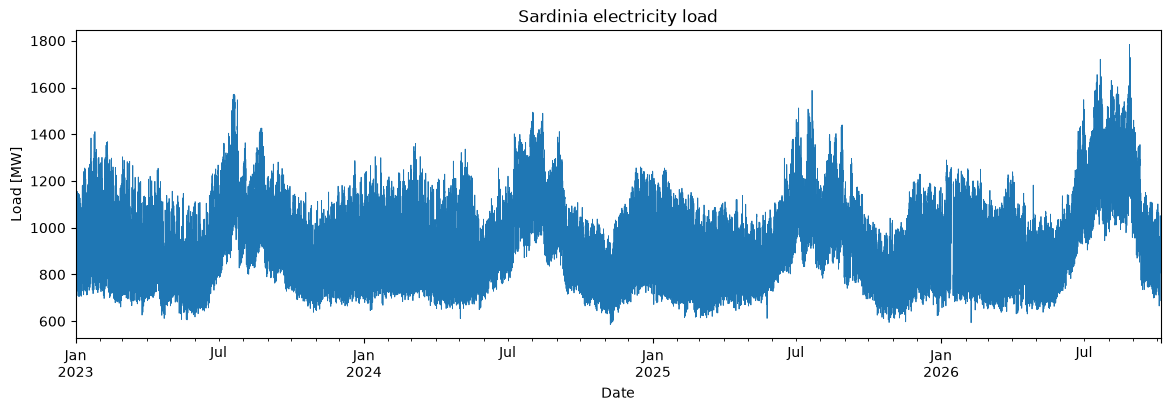

In [3]:
fig, ax = plt.subplots(figsize=(14, 4))

df["Total Load [MW]"].plot(ax=ax, linewidth=0.6)

ax.set_title("Sardinia electricity load")
ax.set_xlabel("Date")
ax.set_ylabel("Load [MW]")

plt.show()

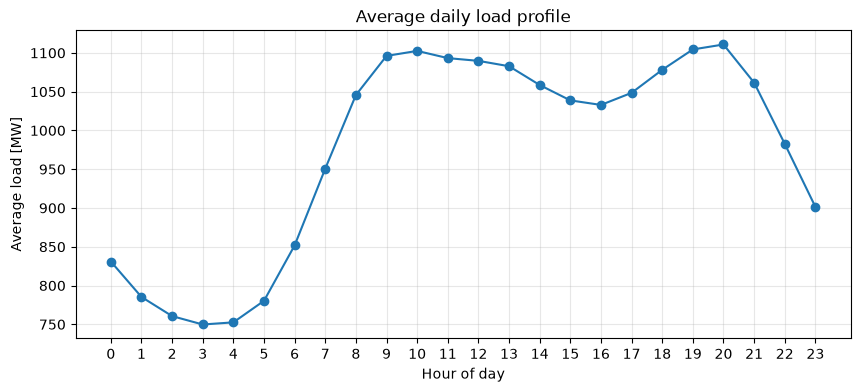

In [4]:
hourly_profile = df.groupby(df.index.hour)["Total Load [MW]"].mean()

fig, ax = plt.subplots(figsize=(10, 4))

hourly_profile.plot(ax=ax, marker="o")

ax.set_title("Average daily load profile")
ax.set_xlabel("Hour of day")
ax.set_ylabel("Average load [MW]")
ax.set_xticks(range(24))
ax.grid(alpha=0.3)

plt.show()

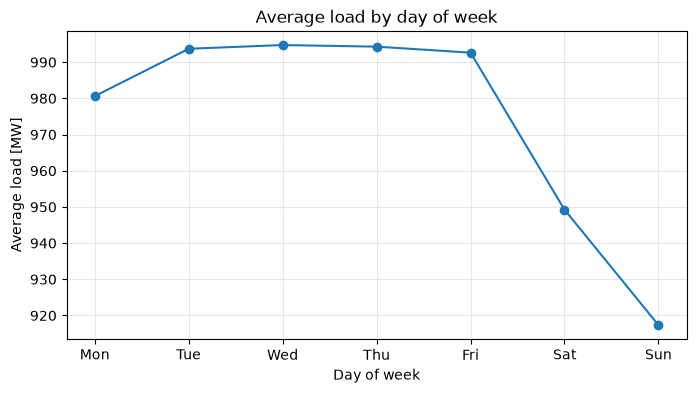

In [5]:
weekday_profile = (
    df.groupby(df.index.dayofweek)["Total Load [MW]"]
      .mean()
)

weekday_profile.index = [
    "Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"
]

fig, ax = plt.subplots(figsize=(8, 4))

weekday_profile.plot(ax=ax, marker="o")

ax.set_title("Average load by day of week")
ax.set_xlabel("Day of week")
ax.set_ylabel("Average load [MW]")
ax.grid(alpha=0.3)

plt.show()

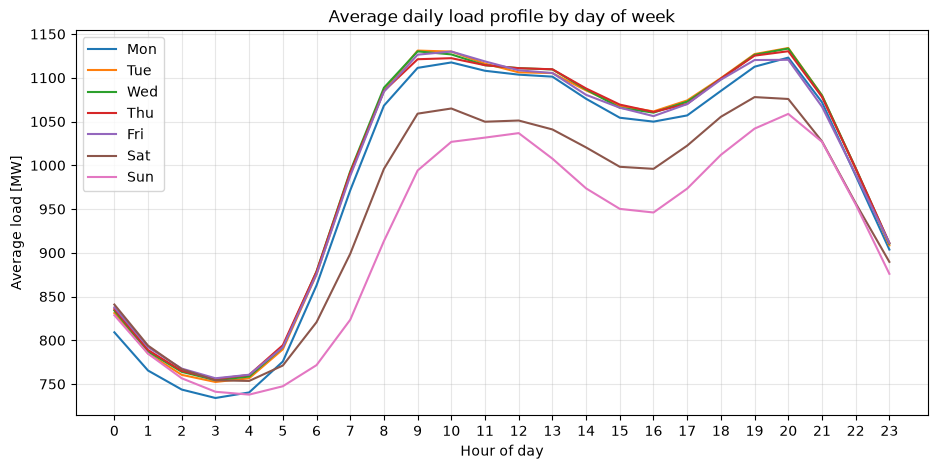

In [6]:
profile = (
    df.assign(
        hour=df.index.hour,
        weekday=df.index.dayofweek
    )
    .groupby(["weekday", "hour"])["Total Load [MW]"]
    .mean()
    .unstack(0)
)

profile.columns = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

fig, ax = plt.subplots(figsize=(11, 5))

profile.plot(ax=ax)

ax.set_title("Average daily load profile by day of week")
ax.set_xlabel("Hour of day")
ax.set_ylabel("Average load [MW]")
ax.set_xticks(range(24))
ax.grid(alpha=0.3)

plt.show()

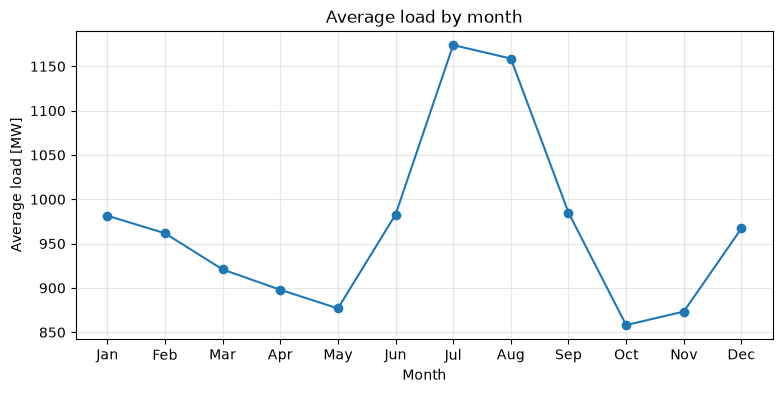

In [12]:
monthly_profile = (
    df.groupby(df.index.month)["Total Load [MW]"]
      .mean()
)

monthly_profile.index = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

fig, ax = plt.subplots(figsize=(9, 4))

monthly_profile.plot(ax=ax, marker="o")

ax.set_title("Average load by month")
ax.set_xlabel("Month")
ax.set_ylabel("Average load [MW]")
ax.set_xticks(range(12))
ax.set_xticklabels(monthly_profile.index)
ax.grid(alpha=0.3)

plt.show()

In [8]:
load = df["Total Load [MW]"]

print(f"Lag 24h:  {load.corr(load.shift(24)):.3f}")
print(f"Lag 168h: {load.corr(load.shift(168)):.3f}")

Lag 24h:  0.944
Lag 168h: 0.902


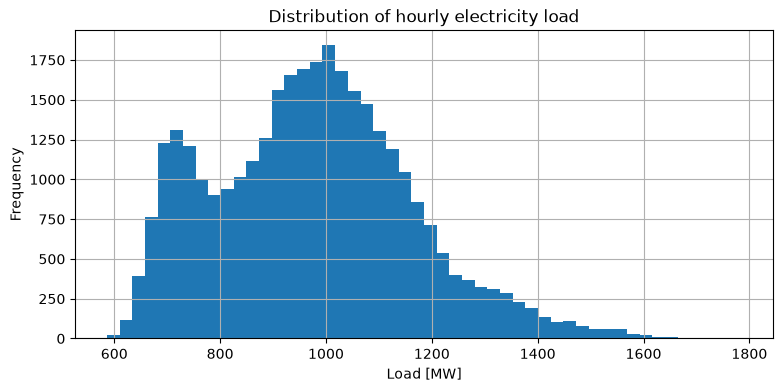

count    32927.000000
mean       974.587243
std        188.373592
min        585.979500
25%        833.563875
50%        972.809250
75%       1092.694625
max       1784.089500
Name: Total Load [MW], dtype: float64


In [15]:
fig, ax = plt.subplots(figsize=(9, 4))

df["Total Load [MW]"].hist(bins=50, ax=ax)

ax.set_title("Distribution of hourly electricity load")
ax.set_xlabel("Load [MW]")
ax.set_ylabel("Frequency")

plt.show()

print(df["Total Load [MW]"].describe())